In [19]:
# ==============================================================
# Notebook 11
# Gaussian Mixture Model (GMM) Flight Anomaly Detection
# Intelligent Flight Operations Analytics and Decision Support Dashboard
# ==============================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# Evaluation
from sklearn.metrics import silhouette_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print("=" * 60)
print("Gaussian Mixture Model Notebook Started Successfully")
print("=" * 60)

Gaussian Mixture Model Notebook Started Successfully


In [20]:
# ==============================================================
# Load Dataset
# ==============================================================

df = pd.read_csv("../data/final/information_overload_mitigation_dataset.csv")

print("Dataset Loaded Successfully")
print()
print("Dataset Shape :", df.shape)

Dataset Loaded Successfully

Dataset Shape : (7516, 82)


In [21]:
# First Five Records

df.head()

,icao24,callsign,origin_country,time_position,last_constant,longitude,latitude,baro_altitude,on_ground,velocity,true_track,vertical_rate,geo_altitude,squawk,spi,position_source,flight_phase,speed_category,altitude_band,vertical_movement,heading_direction,operational_risk,N-NUMBER,SERIAL NUMBER,MFR MDL CODE,ENG MFR MDL,YEAR MFR,TYPE REGISTRANT,LAST ACTION DATE,CERT ISSUE DATE,CERTIFICATION,TYPE AIRCRAFT,TYPE ENGINE,STATUS CODE,MODE S CODE,AIR WORTH DATE,EXPIRATION DATE,UNIQUE ID,MODE S CODE HEX,MANUFACTURER,AIRCRAFT_MODEL,AIRCRAFT_TYPE_CODE,ENGINE_TYPE_CODE,AIRCRAFT_CATEGORY,BUILD_CERTIFICATE,NUMBER_OF_ENGINES,SEAT_CAPACITY,WEIGHT_CLASS,CRUISE_SPEED,TYPE_CERTIFICATE,CERTIFICATE_HOLDER,Aircraft_Age,Aircraft_Age_Category,Engine_Configuration,Seat_Capacity_Category,Weight_Category,Cruise_Speed_Category,Manufacturer_Group,Aircraft_Size_Category,distance_to_airport_km,nearest_ident,nearest_name,nearest_municipality,nearest_iso_country,nearest_airport_size,nearest_airport_category,nearest_airport_importance,nearest_latitude_deg,nearest_longitude_deg,nearest_lat_rad,nearest_lon_rad,datetime,Distance_Risk_Level,Airport_Operational_Profile,Aircraft_Operational_Capability,Operational_Complexity_Index,Operational_Complexity_Level,Flight_Operational_Score,Flight_Operational_Priority,Smart_Alert_Priority,Information_Filter_Level,Decision_Support_Recommendation
0,80162D,AXB848,India,1.767745e+09,1767745048,52.7391,25.4425,9608.82,False,257.34,119.59,5.20,9829.80,3112.0,False,0,Climb,Cruise Speed,High Altitude,Climbing,East,Medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.199726,OMAS,Das Island Airport,Das Island,AE,Small,Local,Low,25.138234,52.874429,0.438745,0.922833,2026-01-07 00:17:28,Remote,Local Airport,Unknown,7,Medium,6,Low,Low,Background Monitoring,Background Monitoring
1,AE1FA0,72209,United States,1.767745e+09,1767745047,-84.9380,38.1463,571.50,False,73.38,12.96,0.33,487.68,NaN,False,0,Cruise,Low Speed,Low Altitude,Level Flight,North,Low,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.518443,05KT,High Point Farm Airport,Frankfort,US,Small,Local,Low,38.187091,-84.930110,0.666490,-1.482310,2026-01-07 00:17:27,Close,Local Airport,Unknown,6,Medium,8,Medium,Medium,Standard Monitoring,Routine Monitoring
2,AC96B8,AAL1175,United States,1.767745e+09,1767745048,-102.0238,34.0962,10363.20,False,196.90,291.13,0.00,10683.24,NaN,False,0,Cruise,Cruise Speed,Cruise Altitude,Level Flight,West,Low,910AN,29512,13844CB,13802.0,1999.0,3.0,2023-10-20,1999-05-27,1T,5.0,5.0,V,53113270.0,1999-05-25,2030-04-30,927071.0,AC96B8,BOEING,737-823,5.0,5.0,1.0,0.0,2.0,162.0,CLASS 3,0.0,,...,27.0,Mid-Life,Twin Engine,Medium Commercial,Heavy,Unknown,Commercial,Narrow-Body,51.550924,1TX5,Laney Farm Airport,Hale Center,US,Small,Local,Low,34.126017,-101.908751,0.595611,-1.778643,2026-01-07 00:17:28,Moderate,Local Airport,High Capability,8,Medium,9,Medium,Medium,Standard Monitoring,Routine Monitoring
3,C81BD3,ZKAMK,New Zealand,1.767745e+09,1767744917,174.5408,-35.8060,624.84,False,56.90,165.34,0.65,670.56,NaN,False,0,Cruise,Low Speed,Low Altitude,Level Flight,South,Low,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.487628,NZ-0085,Tahere Airstrip,Whareora,NZ,Small,Local,Low,-35.696260,174.436410,-0.623017,3.044490,2026-01-07 00:15:17,Close,Local Airport,Unknown,6,Medium,8,Medium,Medium,Standard Monitoring,Routine Monitoring
4,AA56DB,UAL2447,United States,1.767745e+09,1767745048,-102.7402,37.4696,10972.80,False,200.08,327.49,0.00,11155.68,NaN,False,0,Cruise,Cruise Speed,Cruise Altitude,Level Flight,North,Low,76529,31652,13844BZ,13073.0,2010.0,3.0,2023-09-22,2010-12-29,1T,5.0,5.0,V,52453333.0,2010-12-23,2029-12-31,1060884.0,AA56DB,BOEING,737-824,5.0,5.0,1.0,0.0,2.

In [22]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7516 entries, 0 to 7515
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   icao24                           7516 non-null   str    
 1   callsign                         7500 non-null   str    
 2   origin_country                   7516 non-null   str    
 3   time_position                    7516 non-null   float64
 4   last_constant                    7516 non-null   int64  
 5   longitude                        7516 non-null   float64
 6   latitude                         7516 non-null   float64
 7   baro_altitude                    7516 non-null   float64
 8   on_ground                        7516 non-null   bool   
 9   velocity                         7516 non-null   float64
 10  true_track                       7516 non-null   float64
 11  vertical_rate                    7516 non-null   float64
 12  geo_altitude                   

In [23]:
# Dataset Shape

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 7516
Columns : 82


In [24]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

squawk                    4286
YEAR MFR                  3255
Aircraft_Age              3255
AIR WORTH DATE            3201
ENG MFR MDL               3201
CERTIFICATION             3189
EXPIRATION DATE           3055
CERT ISSUE DATE           3055
SERIAL NUMBER             3049
N-NUMBER                  3049
MFR MDL CODE              3049
ENGINE_TYPE_CODE          3049
TYPE AIRCRAFT             3049
LAST ACTION DATE          3049
TYPE ENGINE               3049
MODE S CODE               3049
STATUS CODE               3049
UNIQUE ID                 3049
MODE S CODE HEX           3049
MANUFACTURER              3049
AIRCRAFT_MODEL            3049
AIRCRAFT_TYPE_CODE        3049
TYPE REGISTRANT           3049
CERTIFICATE_HOLDER        3049
AIRCRAFT_CATEGORY         3049
NUMBER_OF_ENGINES         3049
BUILD_CERTIFICATE         3049
WEIGHT_CLASS              3049
CRUISE_SPEED              3049
TYPE_CERTIFICATE          3049
SEAT_CAPACITY             3049
Weight_Category           3049
Aircraft

In [25]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [26]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
icao24,7516,7514,8.99E+04,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
callsign,7500,7404,UNKNOWN,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin_country,7516,93,United States,4627,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_position,7516.0,NaN,NaN,NaN,1767745013.194651,170.554084,1767739408.0,1767745046.0,1767745048.0,1767745048.0,1767745048.0
last_constant,7516.0,NaN,NaN,NaN,1767745026.682278,59.812134,1767744734.0,1767745047.0,1767745048.0,1767745048.0,1767745048.0
...,...,...,...,...,...,...,...,...,...,...,...
Flight_Operational_Score,7516.0,NaN,NaN,NaN,8.605375,2.258643,4.0,7.0,8.0,10.0,15.0
Flight_Operational_Priority,7516,4,Medium,3836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Smart_Alert_Priority,7516,4,Medium,3811,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Information_Filter_Level,7516,4,Standard Monitoring,3811,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
print("Total Columns :", len(df.columns))

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Total Columns : 82
1. icao24
2. callsign
3. origin_country
4. time_position
5. last_constant
6. longitude
7. latitude
8. baro_altitude
9. on_ground
10. velocity
11. true_track
12. vertical_rate
13. geo_altitude
14. squawk
15. spi
16. position_source
17. flight_phase
18. speed_category
19. altitude_band
20. vertical_movement
21. heading_direction
22. operational_risk
23. N-NUMBER
24. SERIAL NUMBER
25. MFR MDL CODE
26. ENG MFR MDL
27. YEAR MFR
28. TYPE REGISTRANT
29. LAST ACTION DATE
30. CERT ISSUE DATE
31. CERTIFICATION
32. TYPE AIRCRAFT
33. TYPE ENGINE
34. STATUS CODE
35. MODE S CODE
36. AIR WORTH DATE
37. EXPIRATION DATE
38. UNIQUE ID
39. MODE S CODE HEX
40. MANUFACTURER
41. AIRCRAFT_MODEL
42. AIRCRAFT_TYPE_CODE
43. ENGINE_TYPE_CODE
44. AIRCRAFT_CATEGORY
45. BUILD_CERTIFICATE
46. NUMBER_OF_ENGINES
47. SEAT_CAPACITY
48. WEIGHT_CLASS
49. CRUISE_SPEED
50. TYPE_CERTIFICATE
51. CERTIFICATE_HOLDER
52. Aircraft_Age
53. Aircraft_Age_Category
54. Engine_Configuration
55. Seat_Capacity_Category

## 9. Feature Selection for Gaussian Mixture Model

The Gaussian Mixture Model (GMM) is designed to learn the distribution of normal flight behaviour using continuous operational variables.

Decision-support outputs generated by the Information Overload Mitigation Framework (e.g., Flight Operational Score, Smart Alert Priority, and Decision Support Recommendation) are intentionally excluded to prevent information leakage and to ensure that the model learns only from aircraft operational characteristics.

In [28]:
# ==========================================================
# Select Features for GMM
# ==========================================================

gmm_features = [

    "latitude",
    "longitude",
    "velocity",
    "baro_altitude",
    "geo_altitude",
    "vertical_rate",
    "true_track",
    "distance_to_airport_km",
    "Operational_Complexity_Index",
    "on_ground"

]

X = df[gmm_features].copy()

print("Selected Features:")
print("-" * 40)

for feature in gmm_features:
    print(feature)

print("\nFeature Matrix Shape:", X.shape)

Selected Features:
----------------------------------------
latitude
longitude
velocity
baro_altitude
geo_altitude
vertical_rate
true_track
distance_to_airport_km
Operational_Complexity_Index
on_ground

Feature Matrix Shape: (7516, 10)


In [29]:
# ==========================================================
# Missing Values
# ==========================================================

missing = X.isnull().sum()

print(missing)

latitude                        0
longitude                       0
velocity                        0
baro_altitude                   0
geo_altitude                    0
vertical_rate                   0
true_track                      0
distance_to_airport_km          0
Operational_Complexity_Index    0
on_ground                       0
dtype: int64


In [30]:
# ==========================================================
# Summary Statistics
# ==========================================================

X.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,7516.0,29.809020,20.819909,-46.844100,28.719825,34.941100,40.497700,69.902200
longitude,7516.0,-44.505623,89.415081,-175.382200,-101.147850,-83.300000,10.230600,177.560100
velocity,7516.0,156.088623,88.899095,0.000000,67.910000,183.250000,227.780000,743.540000
baro_altitude,7516.0,6789.515301,4176.788758,-68.580000,2223.135000,7924.800000,10660.380000,14935.200000
geo_altitude,7516.0,6903.362115,4226.026196,-45.720000,2286.000000,8042.910000,10645.140000,22387.560000
vertical_rate,7516.0,-0.293391,4.587985,-25.030000,-0.650000,0.000000,0.000000,23.080000
true_track,7516.0,182.542976,102.893421,0.000000,91.225000,185.000000,271.150000,359.840000
distance_to_airport_km,7516.0,45.845165,49.586250,0.049909,13.816159,33.327466,60.169705,494.546453
Operational_Complexity_Index,7516.0,6.912986,1.325681,4.000000,6.000000,7.000000,8.000000,11.000000


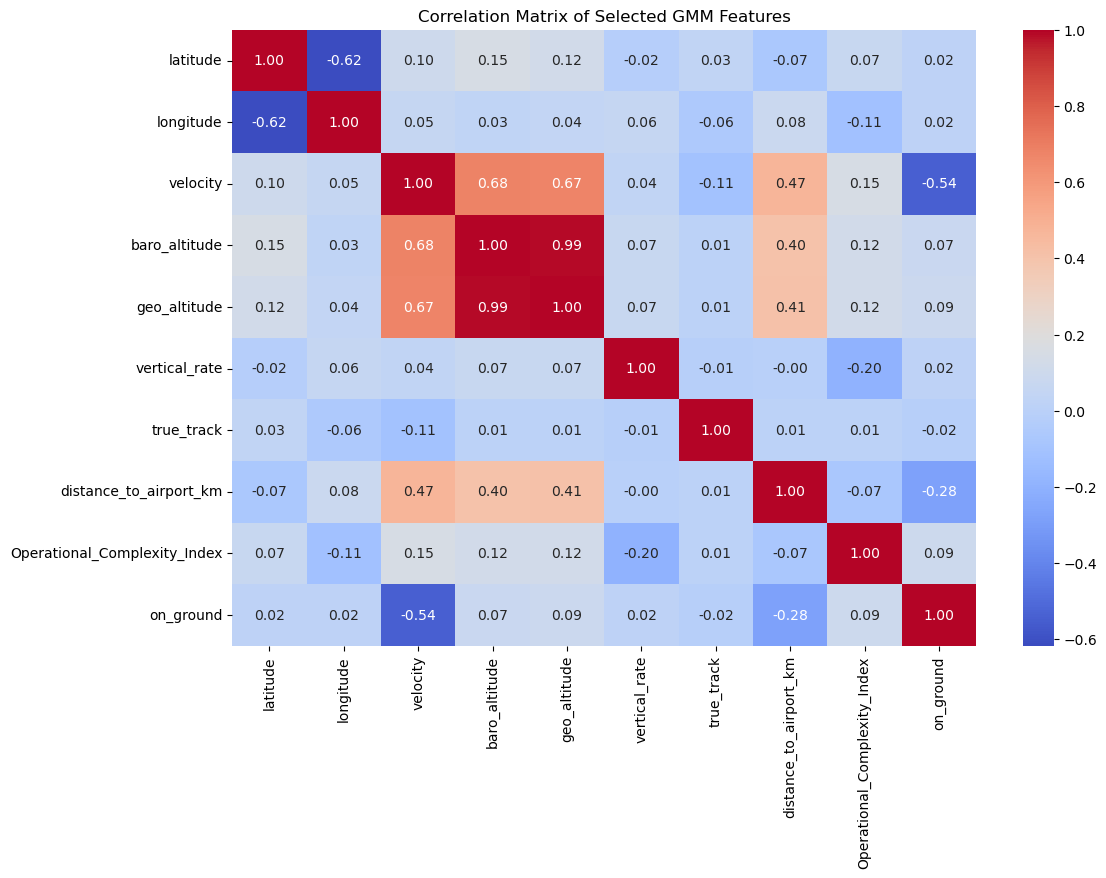

In [31]:
# ==========================================================
# Correlation Matrix
# ==========================================================

correlation_matrix = X.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Selected GMM Features")

plt.show()

In [32]:
# ==========================================================
# Standardize Features
# ==========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

print()

print("Scaled Dataset Shape:", X_scaled.shape)

Feature Scaling Completed

Scaled Dataset Shape: (7516, 10)


In [33]:
# ==========================================================
# Create Scaled DataFrame
# ==========================================================

X_scaled = pd.DataFrame(
    X_scaled,
    columns=gmm_features
)

X_scaled.head()

,latitude,longitude,velocity,baro_altitude,geo_altitude,vertical_rate,true_track,distance_to_airport_km,Operational_Complexity_Index,on_ground
0,-0.209742,1.087637,1.139023,0.675038,0.692526,1.197423,-0.611868,1.398758,0.065642,-0.31971
1,0.400474,-0.452218,-0.930427,-1.488806,-1.518237,0.135884,-1.648252,-0.288945,-0.688737,-0.31971
2,0.205931,-0.643314,0.459106,0.855663,0.894488,0.063952,1.055405,0.115075,0.820021,-0.31971
3,-3.151761,2.449933,-1.115818,-1.476035,-1.474959,0.205636,-0.167203,-0.592089,-0.688737,-0.31971
4,0.367969,-0.651327,0.494879,1.001622,1.006288,0.063952,1.408804,0.416582,0.820021,-0.31971


In [34]:
X_scaled.mean()

latitude                       -2.647046e-17
longitude                      -7.562988e-18
velocity                       -1.569320e-16
baro_altitude                   5.010480e-17
geo_altitude                    1.181717e-16
vertical_rate                   3.497882e-17
true_track                     -4.310903e-16
distance_to_airport_km          4.726868e-18
Operational_Complexity_Index    2.543055e-16
on_ground                      -5.105017e-17
dtype: float64

In [35]:
X_scaled.std()

latitude                        1.000067
longitude                       1.000067
velocity                        1.000067
baro_altitude                   1.000067
geo_altitude                    1.000067
vertical_rate                   1.000067
true_track                      1.000067
distance_to_airport_km          1.000067
Operational_Complexity_Index    1.000067
on_ground                       1.000067
dtype: float64

In [36]:
bic_scores = []
aic_scores = []

n_components = range(1, 21)

for n in n_components:

    gmm = GaussianMixture(
        n_components=n,
        covariance_type="full",
        random_state=42,
        n_init=5,
        max_iter=300
    )

    gmm.fit(X_scaled)

    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))

print("BIC and AIC Calculation Completed")

BIC and AIC Calculation Completed


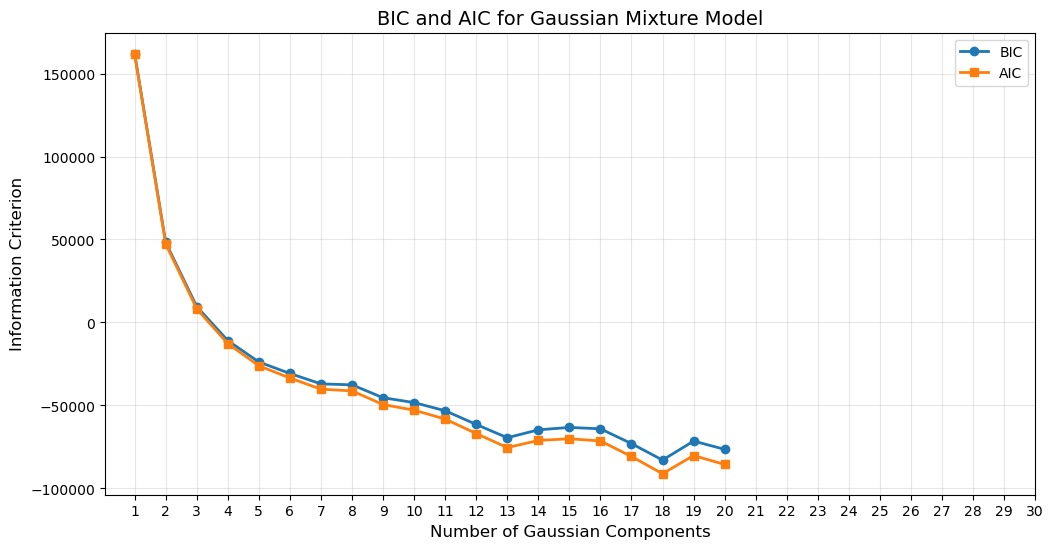

In [37]:
# ==========================================================
# Plot BIC and AIC
# ==========================================================

plt.figure(figsize=(12,6))

plt.plot(n_components, bic_scores, marker='o', linewidth=2, label='BIC')
plt.plot(n_components, aic_scores, marker='s', linewidth=2, label='AIC')

plt.xlabel("Number of Gaussian Components", fontsize=12)
plt.ylabel("Information Criterion", fontsize=12)
plt.title("BIC and AIC for Gaussian Mixture Model", fontsize=14)

plt.xticks(range(1,31))

plt.grid(True, alpha=0.3)

plt.legend()

plt.show()

In [38]:
# ==========================================================
# Best Number of Components
# ==========================================================

best_bic = n_components[np.argmin(bic_scores)]
best_aic = n_components[np.argmin(aic_scores)]

print(f"Best Number of Components (BIC): {best_bic}")
print(f"Best Number of Components (AIC): {best_aic}")

Best Number of Components (BIC): 18
Best Number of Components (AIC): 18


In [50]:
# ==========================================================
# Train Final Gaussian Mixture Model
# ==========================================================

optimal_components = 18

gmm = GaussianMixture(
    n_components=optimal_components,
    covariance_type="full",
    random_state=42,
    n_init=10,
    max_iter=500
)

gmm.fit(X_scaled)

print("Final Gaussian Mixture Model Trained Successfully")

Final Gaussian Mixture Model Trained Successfully


In [52]:
# ==========================================================
# Predict Gaussian Components
# ==========================================================

cluster_labels = gmm.predict(X_scaled)

df["GMM_Cluster"] = cluster_labels

print("Cluster Labels Generated Successfully")

print()

print(df["GMM_Cluster"].value_counts().sort_index())

Cluster Labels Generated Successfully

GMM_Cluster
0      410
1      654
2      491
3      423
4       47
5      594
6      591
7     1067
8       30
9      504
10     128
11      77
12     645
13      55
14    1073
15     499
16     217
17      11
Name: count, dtype: int64


In [53]:
# ==========================================================
# Calculate Log-Likelihood
# ==========================================================

log_likelihood = gmm.score_samples(X_scaled)

df["GMM_Log_Likelihood"] = log_likelihood

print("Log-Likelihood Calculated Successfully")

Log-Likelihood Calculated Successfully


In [54]:
# ==========================================================
# Generate Anomaly Score
# ==========================================================

df["GMM_Anomaly_Score"] = -df["GMM_Log_Likelihood"]

print("Anomaly Scores Generated Successfully")

Anomaly Scores Generated Successfully


In [55]:
# ==========================================================
# Summary Statistics
# ==========================================================

df["GMM_Anomaly_Score"].describe()

count    7516.000000
mean       -6.219444
std         7.468599
min       -24.184383
25%       -11.880434
50%        -6.015279
75%        -0.056320
max        22.257639
Name: GMM_Anomaly_Score, dtype: float64

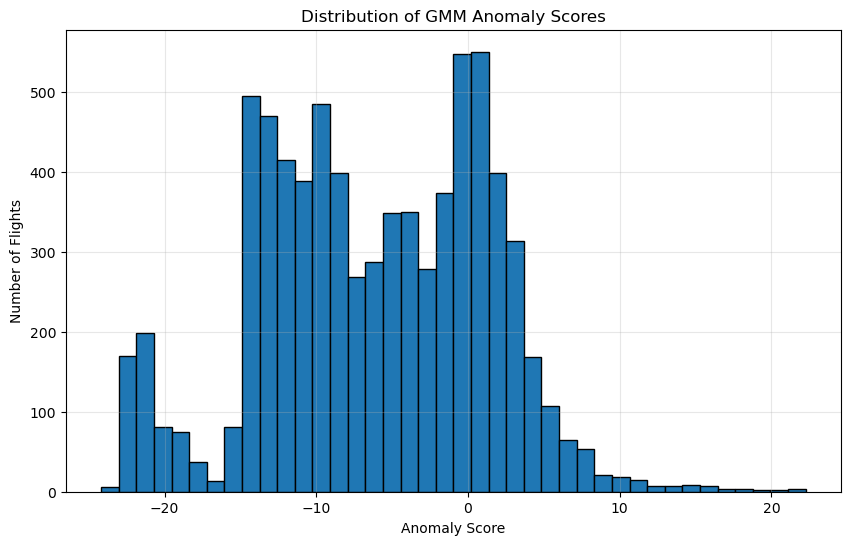

In [56]:
# ==========================================================
# Distribution of Anomaly Scores
# ==========================================================

plt.figure(figsize=(10,6))

plt.hist(
    df["GMM_Anomaly_Score"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of GMM Anomaly Scores")

plt.xlabel("Anomaly Score")

plt.ylabel("Number of Flights")

plt.grid(alpha=0.3)

plt.show()

In [57]:
# ==========================================================
# Normalize GMM Anomaly Score
# ==========================================================

df["GMM_Anomaly_Score"] = (
    df["GMM_Anomaly_Score"]
    - df["GMM_Anomaly_Score"].min()
)

print(df["GMM_Anomaly_Score"].describe())

count    7516.000000
mean       17.964940
std         7.468599
min         0.000000
25%        12.303949
50%        18.169104
75%        24.128063
max        46.442023
Name: GMM_Anomaly_Score, dtype: float64


In [58]:
# ==========================================================
# Determine Anomaly Threshold
# ==========================================================

threshold = df["GMM_Anomaly_Score"].quantile(0.95)

print(f"Anomaly Threshold : {threshold:.2f}")

Anomaly Threshold : 28.63


In [59]:
# ==========================================================
# Label Normal and Anomalous Flights
# ==========================================================

df["GMM_Anomaly_Label"] = np.where(
    df["GMM_Anomaly_Score"] >= threshold,
    "Anomaly",
    "Normal"
)

print(df["GMM_Anomaly_Label"].value_counts())

GMM_Anomaly_Label
Normal     7140
Anomaly     376
Name: count, dtype: int64


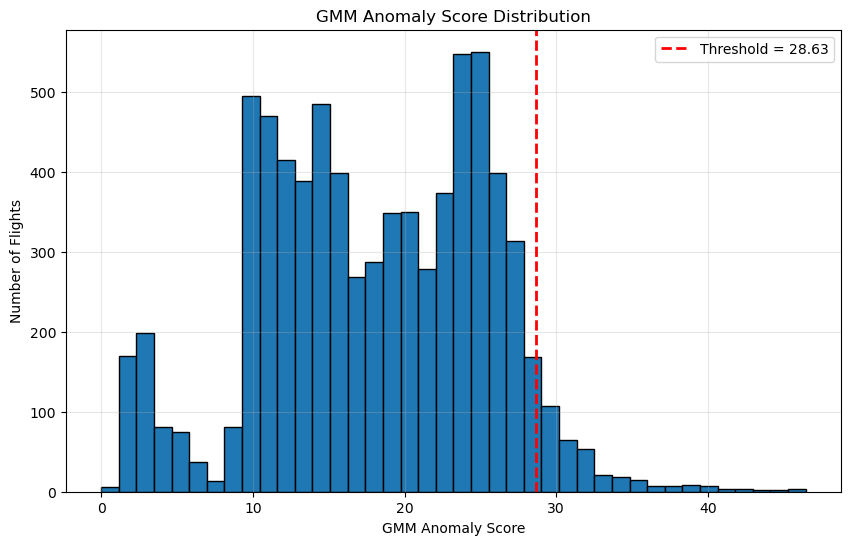

In [60]:
# ==========================================================
# Visualize Anomaly Threshold
# ==========================================================

plt.figure(figsize=(10,6))

plt.hist(
    df["GMM_Anomaly_Score"],
    bins=40,
    edgecolor="black"
)

plt.axvline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {threshold:.2f}"
)

plt.title("GMM Anomaly Score Distribution")

plt.xlabel("GMM Anomaly Score")

plt.ylabel("Number of Flights")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [61]:
# ==========================================================
# Save GMM Results
# ==========================================================

output_path = "../data/final/gmm_anomaly_detection_dataset.csv"

df.to_csv(output_path, index=False)

print("Dataset Saved Successfully")

print()

print("Output File:", output_path)

print()

print("Final Dataset Shape:", df.shape)

Dataset Saved Successfully

Output File: ../data/final/gmm_anomaly_detection_dataset.csv

Final Dataset Shape: (7516, 86)
